<a href="https://www.kaggle.com/code/lalit7881/world-happiness-panel-2005-2025-eda-99-5?scriptVersionId=316688362" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/elvisbui/world-happiness-report-2005-2025-panel/world_happiness_report_2005_2025.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/elvisbui/world-happiness-report-2005-2025-panel/world_happiness_report_2005_2025.csv")

In [3]:
df.head()

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
2111,2025,143,Botswana,3.464,3.335,3.593,1.582,0.989,0.017,0.860,0.022,0.093,-0.099
2112,2025,144,Zimbabwe,3.346,3.244,3.449,1.213,0.782,0.189,0.729,0.056,0.128,0.251
2113,2025,145,Malawi,3.284,3.153,3.415,0.864,0.326,0.299,0.812,0.109,0.143,0.730
2114,2025,146,Sierra Leone,3.251,3.147,3.355,1.054,0.692,0.405,0.800,0.131,0.052,0.117
2115,2025,147,Afghanistan,1.446,1.348,1.544,0.921,0.000,0.176,0.000,0.079,0.131,0.139


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               2116 non-null   int64  
 1   rank_in_year                       2116 non-null   int64  
 2   country                            2116 non-null   object 
 3   happiness_score                    2116 non-null   float64
 4   lower_whisker                      1022 non-null   float64
 5   upper_whisker                      1022 non-null   float64
 6   explained_log_gdp_per_capita       1019 non-null   float64
 7   explained_social_support           1019 non-null   float64
 8   explained_healthy_life_expectancy  1016 non-null   float64
 9   explained_freedom                  1017 non-null   float64
 10  explained_generosity               1019 non-null   float64
 11  explained_corruption               1018 non-null   float

In [6]:
df.describe()

,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465655,5.436091,5.664733,1.265670,1.096746,0.553435,0.609465,0.147343,0.144911,1.736935
std,4.249844,43.845101,1.123870,1.140959,1.107424,0.463823,0.357642,0.229980,0.212070,0.084335,0.118803,0.657497
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619707,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063156,1.305000
50%,2018.000000,76.000000,5.480000,5.592631,5.812000,1.304000,1.140119,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290110,6.486500,1.636000,1.382000,0.712325,0.735000,0.195477,0.181330,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


In [7]:
df.isnull().sum()

year                                    0
rank_in_year                            0
country                                 0
happiness_score                         0
lower_whisker                        1094
upper_whisker                        1094
explained_log_gdp_per_capita         1097
explained_social_support             1097
explained_healthy_life_expectancy    1100
explained_freedom                    1099
explained_generosity                 1097
explained_corruption                 1098
dystopia_plus_residual               1103
dtype: int64

In [8]:
df.dtypes

year                                   int64
rank_in_year                           int64
country                               object
happiness_score                      float64
lower_whisker                        float64
upper_whisker                        float64
explained_log_gdp_per_capita         float64
explained_social_support             float64
explained_healthy_life_expectancy    float64
explained_freedom                    float64
explained_generosity                 float64
explained_corruption                 float64
dystopia_plus_residual               float64
dtype: object

In [9]:
df.shape

(2116, 13)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['year', 'rank_in_year', 'country', 'happiness_score', 'lower_whisker',
       'upper_whisker', 'explained_log_gdp_per_capita',
       'explained_social_support', 'explained_healthy_life_expectancy',
       'explained_freedom', 'explained_generosity', 'explained_corruption',
       'dystopia_plus_residual'],
      dtype='object')

In [12]:
df.nunique()

year                                   14
rank_in_year                          158
country                               168
happiness_score                      1673
lower_whisker                         903
upper_whisker                         927
explained_log_gdp_per_capita          802
explained_social_support              785
explained_healthy_life_expectancy     680
explained_freedom                     668
explained_generosity                  436
explained_corruption                  479
dystopia_plus_residual                869
dtype: int64

## EDA

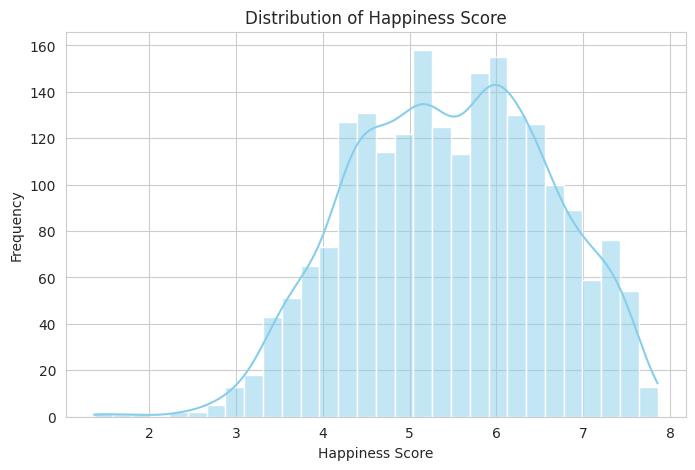

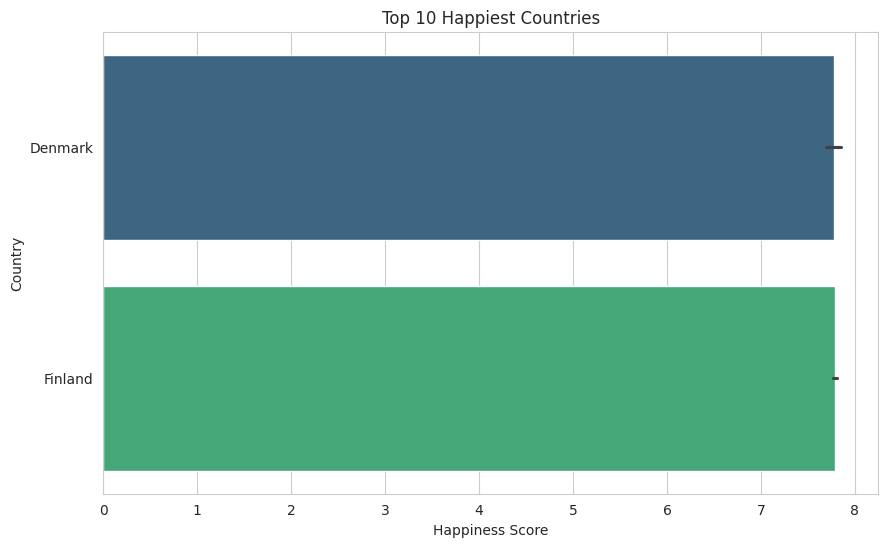

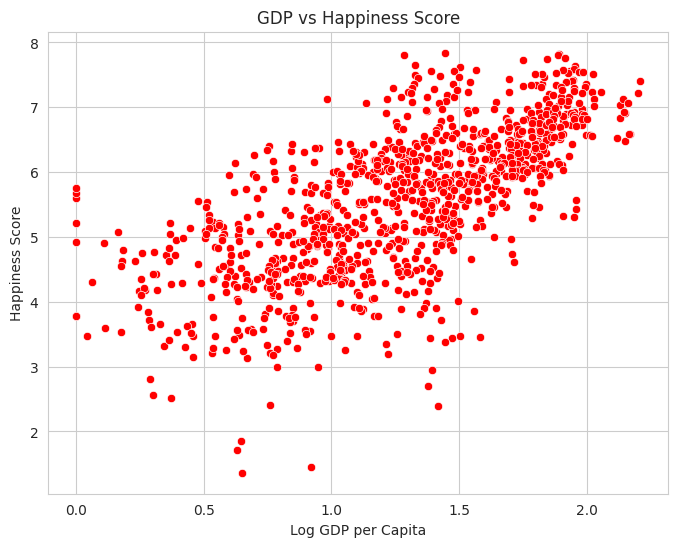

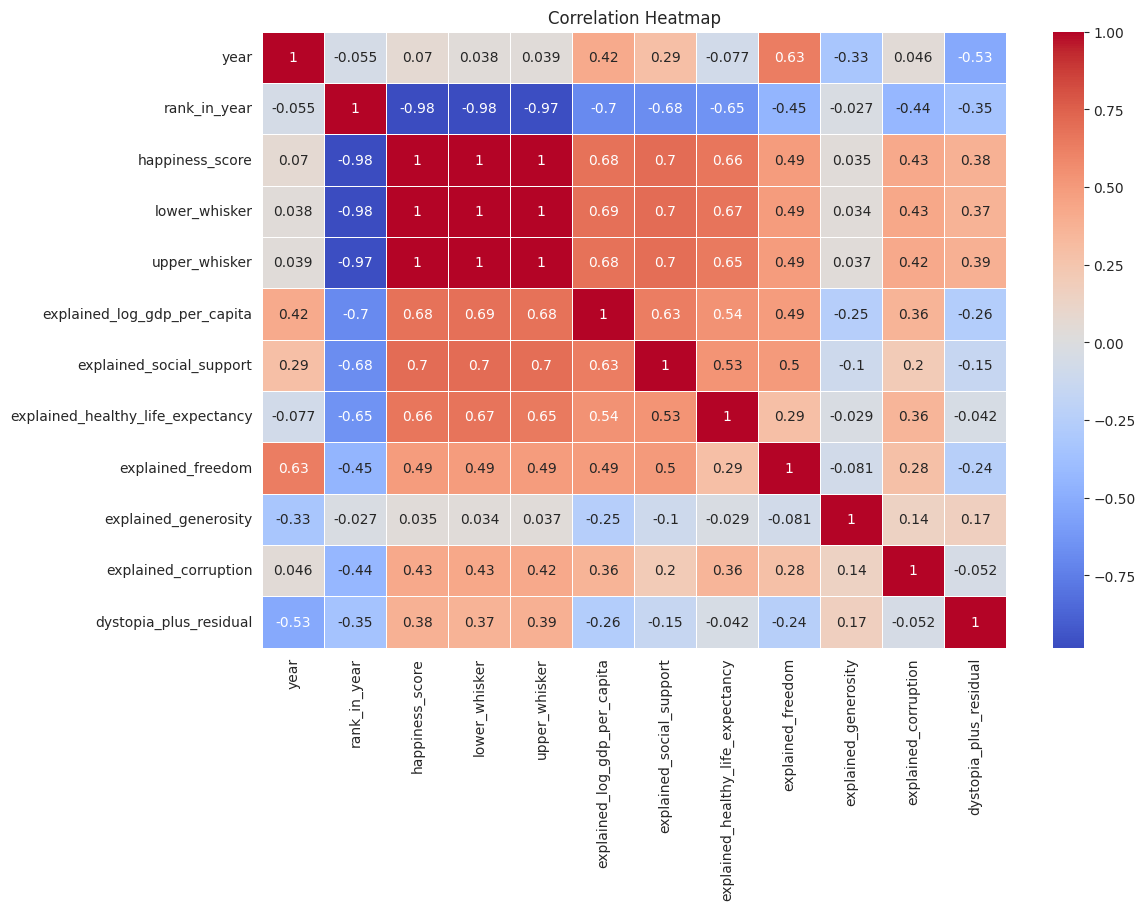

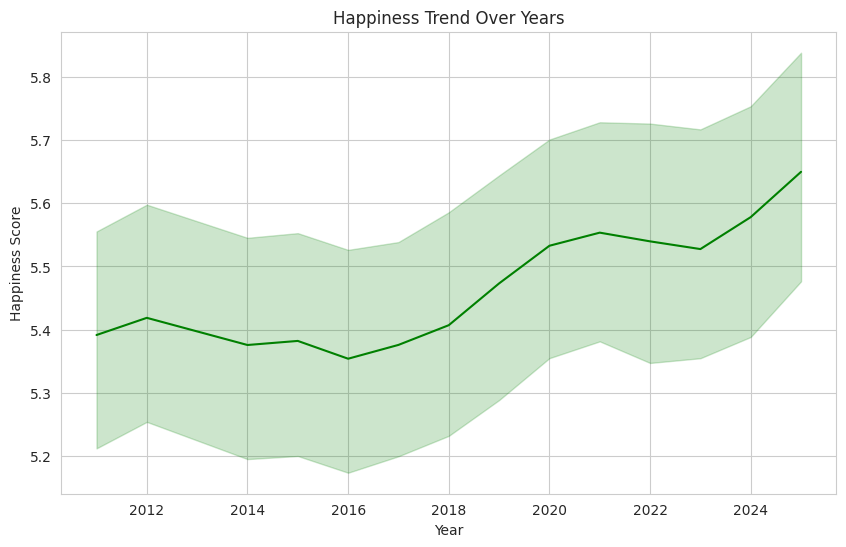

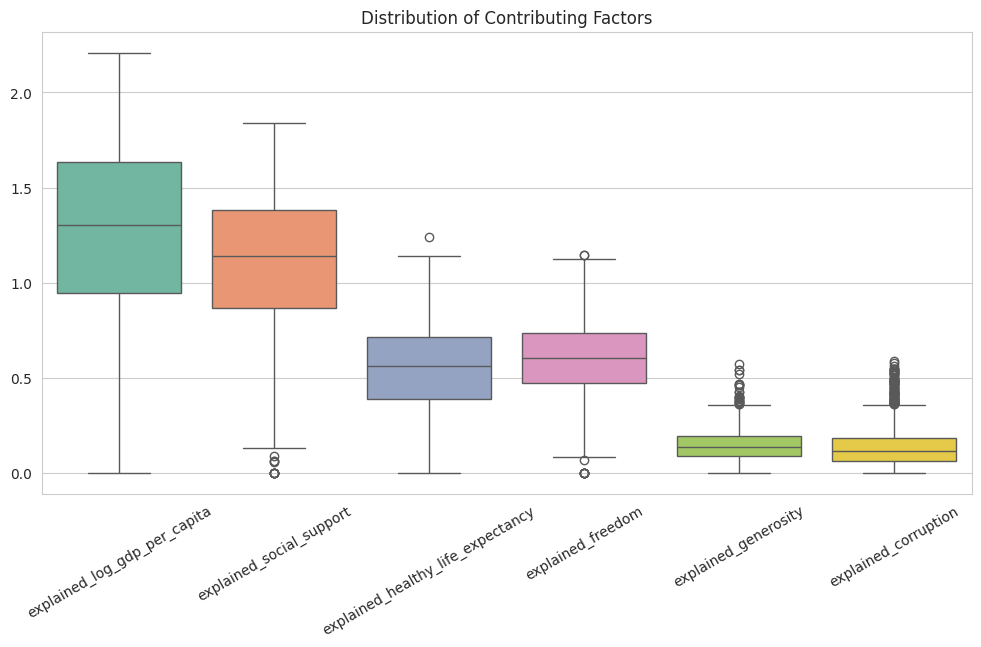

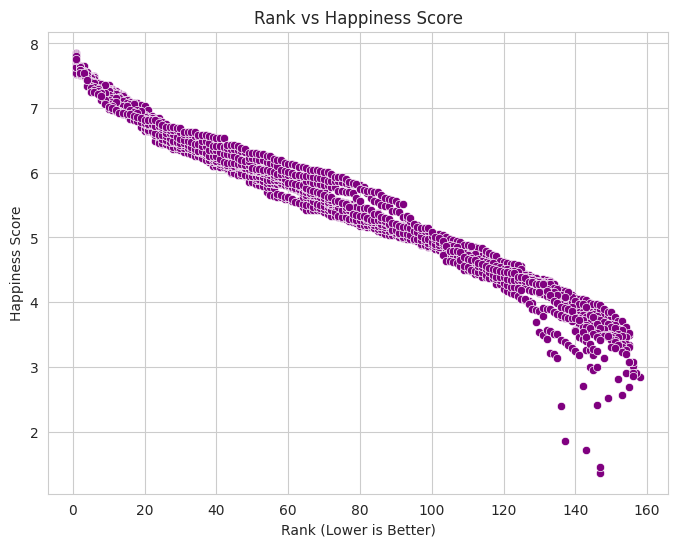

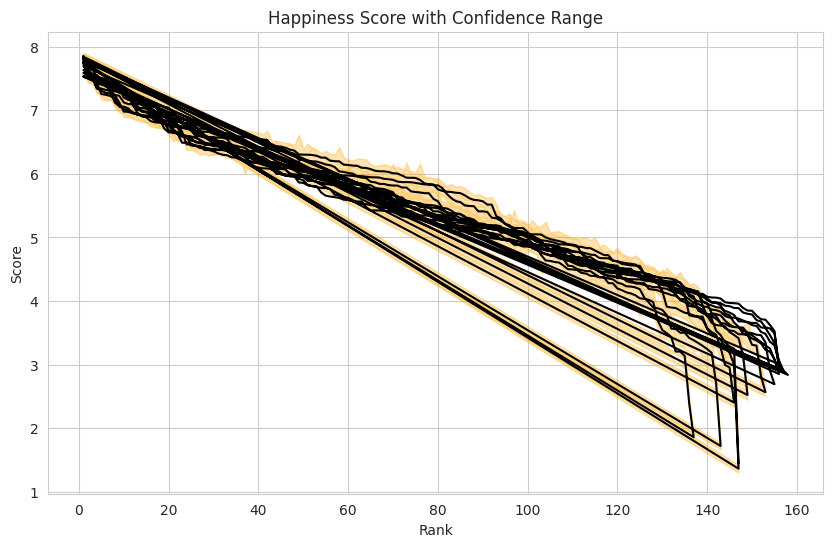

In [13]:
# Style
sns.set_style("whitegrid")

# ================================
# 1. HAPPINESS SCORE DISTRIBUTION
# ================================
plt.figure(figsize=(8,5))
sns.histplot(df['happiness_score'], bins=30, color='skyblue', kde=True)
plt.title("Distribution of Happiness Score")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.show()

# ================================
# 2. TOP 10 HAPPIEST COUNTRIES
# ================================
top10 = df.sort_values(by='happiness_score', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top10,
    x='happiness_score',
    y='country',
    palette='viridis'
)
plt.title("Top 10 Happiest Countries")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.show()

# ================================
# 3. GDP vs HAPPINESS (SCATTER)
# ================================
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='explained_log_gdp_per_capita',
    y='happiness_score',
    color='red'
)
plt.title("GDP vs Happiness Score")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Happiness Score")
plt.show()

# ================================
# 4. CORRELATION HEATMAP
# ================================
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

# ================================
# 5. YEARLY HAPPINESS TREND
# ================================
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x='year',
    y='happiness_score',
    color='green'
)
plt.title("Happiness Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.show()

# ================================
# 6. FACTORS CONTRIBUTION (BOXPLOT)
# ================================
plt.figure(figsize=(12,6))

factors = [
    'explained_log_gdp_per_capita',
    'explained_social_support',
    'explained_healthy_life_expectancy',
    'explained_freedom',
    'explained_generosity',
    'explained_corruption'
]

sns.boxplot(data=df[factors], palette="Set2")

plt.xticks(rotation=30)
plt.title("Distribution of Contributing Factors")
plt.show()

# ================================
# 7. RANK VS HAPPINESS
# ================================
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='rank_in_year',
    y='happiness_score',
    color='purple'
)
plt.title("Rank vs Happiness Score")
plt.xlabel("Rank (Lower is Better)")
plt.ylabel("Happiness Score")
plt.show()

# ================================
# 8. WHISKER RANGE VISUALIZATION
# ================================
plt.figure(figsize=(10,6))
plt.fill_between(
    df['rank_in_year'],
    df['lower_whisker'],
    df['upper_whisker'],
    color='orange',
    alpha=0.3
)
plt.plot(df['rank_in_year'], df['happiness_score'], color='black')
plt.title("Happiness Score with Confidence Range")
plt.xlabel("Rank")
plt.ylabel("Score")
plt.show()

## Feature engineering


Logistic Regression Accuracy: 0.9953

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       212
           1       1.00      1.00      1.00       212

    accuracy                           1.00       424
   macro avg       1.00      1.00      1.00       424
weighted avg       1.00      1.00      1.00       424


Decision Tree Accuracy: 0.9953

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       212
           1       1.00      0.99      1.00       212

    accuracy                           1.00       424
   macro avg       1.00      1.00      1.00       424
weighted avg       1.00      1.00      1.00       424


Random Forest Accuracy: 0.9906

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       212
           1   

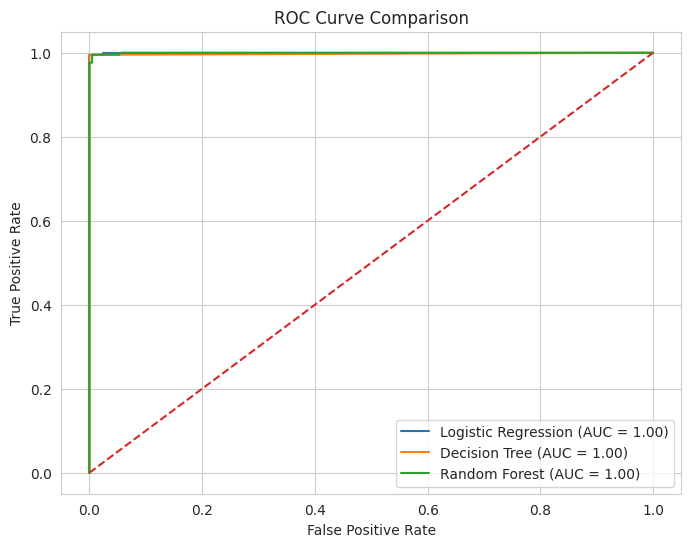


Best Model: Logistic Regression
Best Accuracy: 0.9952830188679245


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# =========================================
# TARGET CREATION
# =========================================
df['target'] = (df['happiness_score'] > df['happiness_score'].median()).astype(int)

# =========================================
# DROP LEAKAGE COLUMNS
# =========================================
df = df.drop(columns=[
    'happiness_score',
    'lower_whisker',
    'upper_whisker'
])

# =========================================
# LABEL ENCODING
# =========================================
le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])

# =========================================
# FEATURES & TARGET
# =========================================
X = df.drop(columns=['target'])
y = df['target']

# =========================================
# TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# PIPELINES (IMPUTER + SCALER + MODEL)
# =========================================
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression())
    ]),
    
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", DecisionTreeClassifier(max_depth=5))
    ]),
    
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

# =========================================
# TRAIN + EVALUATE
# =========================================
results = {}

plt.figure(figsize=(8,6))

for name, pipe in models.items():
    
    # Train (imputer learns ONLY from train)
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    
    # Report
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    
    results[name] = acc

# =========================================
# ROC CURVE
# =========================================
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# =========================================
# BEST MODEL
# =========================================
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])

## Thank you...pls upvote!!!!!